In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('../sentence_dataframe.tsv', sep='\t')
len(df), df.columns

(624335, Index(['text_it', 'text_en', 'hash'], dtype='object'))

In [18]:
df['term_length_it'] = df['text_it'].str.split().apply(len)
df['term_length_en'] = df['text_en'].str.split().apply(len)
df['char_length_it'] = df['text_it'].str.len()
df['char_length_en'] = df['text_en'].str.len()

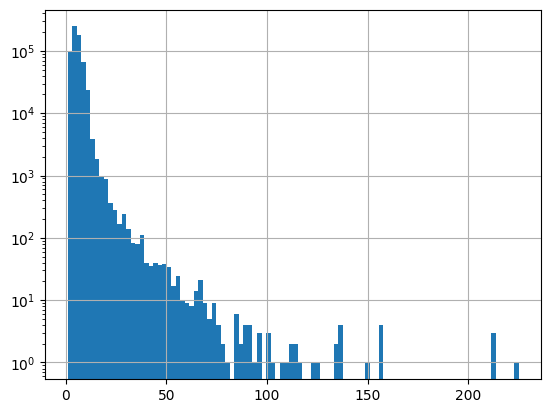

In [19]:
df['term_length_it'].hist(bins=100)
plt.yscale('log')

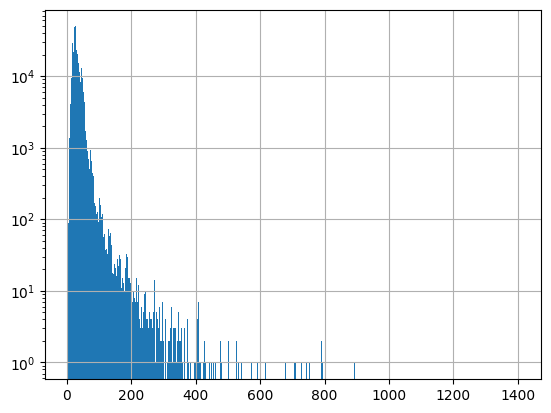

In [20]:
df['char_length_it'].hist(bins=1000)
plt.yscale('log')

<Axes: >

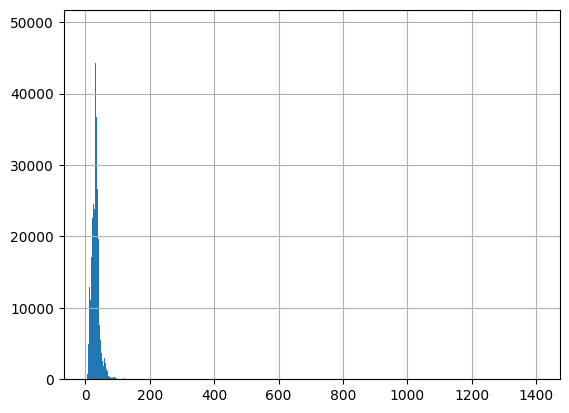

In [21]:
df['char_length_it'].hist(bins=1000)

In [22]:
print(len(df))
df = df[df['char_length_it'] < 50]
print(len(df))

624335
577993


In [23]:
df.sort_values(by='char_length_it', ascending=False).head(20)

,text_it,text_en,hash,term_length_it,term_length_en,char_length_it,char_length_en
138436,Voi avete mai assaggiato una minestra così buona?,Have you ever tasted such a good soup?,5efbd5ba-8036-5bc8-9867-e38d9e89622d,8,8,49,38
507156,C'è anche un'edizione francese di questo romanzo.,There's also a French edition of this novel.,15d1d72b-e856-52cd-9484-bb4df48d4997,7,8,49,44
126949,"Noi lavoriamo per l'eternità, non per il momento.","We work for eternity, not for the moment.",715850cc-d24c-512f-a6e0-f63aa2175a39,8,8,49,41
126947,E aprite il vostro libro di testo a pagina dieci.,And open your textbook at page ten.,34b4533b-882c-52ec-bba4-e7779aa31d49,10,7,49,35
126858,Io gliel'avevo detto che avevamo molto in comune.,I told you we had a lot in common.,62c53dec-da23-54f0-a987-c79938966fa2,8,9,49,34
4038,Quell'edificio con il tetto marrone è una chiesa.,That building whose roof is brown is a church.,c2063330-bf5b-5fc2-ad15-551c84a33b6c,8,9,49,46
126853,Ve l'avevo detto che noi avevamo molto in comune.,I told you we had a lot in common.,85eca333-831f-5667-8ed8-7f7eea62d3df,9,9,49,34
126851,Te l'avevo detto che noi avevamo molto in comune.,I told you we had a lot in common.,13a7892a-3e79-5f8e-80e8-91ddbdb4112a,9,9,49,34
449164,Dicono che anche loro hanno bisogno di una pausa.,"They say they need a break, too.",47d214db-a873-5384-ae09-43b4e88d604f,9,7,49,32
32273,Non dovresti davvero usare del software piratato.,You really shouldn't use pirated software.,bb0fd791-b6ca-59c1-8af5-ec42fcd32756,7,6,49,42


In [24]:
import os
import sys
from tqdm import tqdm
import pandas as pd

sys.path.append('/Users/stevie/repos/lingo_kit_data/vocabulary')
from stanza_tokenizer import StanzaTokenizer

In [25]:
tokenizer = StanzaTokenizer()

2025-11-15 22:04:28 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-11-15 22:04:28 INFO: Downloaded file to /Users/stevie/stanza_resources/resources.json
2025-11-15 22:04:28 WARNING: Language it package default expects mwt, which has been added
2025-11-15 22:04:29 INFO: Loading these models for language: it (Italian):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined          |
| pos       | combined_charlm   |
| lemma     | combined_nocharlm |
| depparse  | combined_charlm   |

2025-11-15 22:04:29 INFO: Using device: cpu
2025-11-15 22:04:29 INFO: Loading: tokenize
2025-11-15 22:04:29 INFO: Loading: mwt
2025-11-15 22:04:29 INFO: Loading: pos
2025-11-15 22:04:30 INFO: Loading: lemma
2025-11-15 22:04:30 INFO: Loading: depparse
2025-11-15 22:04:30 INFO: Done loading 

In [26]:
text = "l'altro lato della strada. L'ALTRO LATO DELLA STRADA. l'altro lato della strada."
tokens = tokenizer.tokenize(text)
for token in tokens:
    print(token)

{'text': "l'", 'lemma': 'il', 'pos': 'DET', 'xpos': 'RD', 'head': 4, 'deprel': 'det', 'feats': 'Definite=Def|Gender=Masc|Number=Sing|PronType=Art|Number=Plur', 'parts_lemma': 'il', 'parts_pos': 'DET', 'vector': None, 'token_hash': '79de0ccb-2172-5399-b99f-ade09a88c14d', 'group_hash': 'e5de14ca-b785-57e7-ae0b-4d8d72b47700'}
{'text': 'altro', 'lemma': 'altro', 'pos': 'ADJ', 'xpos': 'A', 'head': 4, 'deprel': 'amod', 'feats': 'Gender=Masc|Number=Sing', 'parts_lemma': 'altro', 'parts_pos': 'ADJ', 'vector': None, 'token_hash': 'c95456e3-02d6-56fa-929a-c3e823f292db', 'group_hash': 'e1c6b3b4-0412-5560-a3f5-020dafc9461e'}
{'text': 'lato', 'lemma': 'lato', 'pos': 'NOUN', 'xpos': 'S', 'head': 0, 'deprel': 'root', 'feats': 'Gender=Masc|Number=Sing', 'parts_lemma': 'lato', 'parts_pos': 'NOUN', 'vector': None, 'token_hash': '110d7b4e-137a-5209-8c06-0f5d41525453', 'group_hash': '2d41d801-cab6-540f-a1b6-d7760a60ffbe'}
{'text': 'della', 'lemma': 'di', 'pos': 'ADP', 'xpos': 'E', 'head': 7, 'deprel': 'ca

In [27]:
def get_token_key(token_dict):
    return f"{token_dict['text']}_{token_dict['lemma']}_{token_dict['pos']}"

In [28]:
pos_counts = {}
for i, sentence in tqdm(enumerate(df['text_it'])):
    tokens = tokenizer.tokenize(sentence)
    for token in tokens:
        pos = token['pos']
        if pos not in pos_counts:
            pos_counts[pos] = []
        pos_counts[pos].append(token)
    if i > 1000:
        break
print(pos_counts)

1001it [00:44, 22.37it/s]

{'AUX': [{'text': 'devo', 'lemma': 'dovere', 'pos': 'AUX', 'xpos': 'VM', 'head': 2, 'deprel': 'aux', 'feats': 'Mood=Ind|Number=Sing|Person=1|Tense=Pres|VerbForm=Fin', 'parts_lemma': 'dovere', 'parts_pos': 'AUX', 'vector': None, 'token_hash': 'aef68ffd-0d66-5778-a7cf-3eb3044bfa51', 'group_hash': '75273cd9-5002-5b22-b8fb-74df7416d0e2'}, {'text': 'è', 'lemma': 'essere', 'pos': 'AUX', 'xpos': 'VA', 'head': 2, 'deprel': 'cop', 'feats': 'Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin', 'parts_lemma': 'essere', 'parts_pos': 'AUX', 'vector': None, 'token_hash': 'd05e0172-8c49-5787-87f1-9016a42d14f2', 'group_hash': '3a4ed285-f371-52af-9a51-996aedf5a772'}, {'text': 'è', 'lemma': 'essere', 'pos': 'AUX', 'xpos': 'VA', 'head': 6, 'deprel': 'cop', 'feats': 'Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin', 'parts_lemma': 'essere', 'parts_pos': 'AUX', 'vector': None, 'token_hash': 'd05e0172-8c49-5787-87f1-9016a42d14f2', 'group_hash': '3a4ed285-f371-52af-9a51-996aedf5a772'}, {'text': 'sei

In [29]:
pos_counts.keys()

dict_keys(['AUX', 'VERB', 'ADP', 'PUNCT', 'DET', 'PRON', 'NOUN', 'PROPN', 'ADV', 'NUM', 'ADJ', 'CCONJ', 'SCONJ', 'X', 'INTJ'])

In [30]:
bad_pos = ['X', 'PUNCT', 'PROPN', 'NUM']
# POS = 'INTJ'
# POS = 'NUM'
POS = 'ADP'
for i, token in enumerate(pos_counts[POS]):
    print(get_token_key(token))
    if i > 20:
        break

a_a_ADP
d'_di_ADP
per_per_ADP
dei_di_ADP
in_in_ADP
di_di_ADP
di_di_ADP
in_in_ADP
dopo_dopo_ADP
senza_senza_ADP
a_a_ADP
dal_da_ADP
d'_di_ADP
per_per_ADP
a_a_ADP
per_per_ADP
di_di_ADP
a_a_ADP
in_in_ADP
da_da_ADP
con_con_ADP
da_da_ADP


In [31]:
# gram2_dict = {}
# iter_df = df[:10000]
# for sentence in tqdm(iter_df['text_it'], total=len(iter_df)):
#     tokens = tokenizer.tokenize(sentence)
#     for i in range(len(tokens)-1):
#         t1 = tokens[i]
#         t2 = tokens[i+1]
#         if t1['pos'] in bad_pos or t2['pos'] in bad_pos:
#             continue
#         gram2 = (get_token_key(t1), get_token_key(t2))
#         if gram2 not in gram2_dict:
#             gram2_dict[gram2] = 0
#         gram2_dict[gram2] += 1

gram2_dict = {}
iter_df = df[:5000]
for sentence in tqdm(iter_df['text_it'], total=len(iter_df)):
    start_word_count = {}
    end_word_count = {}
    tokens = tokenizer.tokenize(sentence)
    for i in range(len(tokens)-2):
        t1 = tokens[i]
        t2 = tokens[i+1]

        # keep track of the index of 'find' words
        if t1['text'].lower() not in start_word_count:
            start_word_count[t1['text'].lower()] = -1
        start_word_count[t1['text'].lower()] += 1
        if t2['text'].lower() not in end_word_count:
            end_word_count[t2['text'].lower()] = -1
        end_word_count[t2['text'].lower()] += 1

        if t1['pos'] in bad_pos or t2['pos'] in bad_pos:
            continue

        gram2 = (get_token_key(t1), get_token_key(t2))
        
        start_index = sentence.lower().find(t1['text'].lower(), start_word_count[t1['text'].lower()])
        end_index = sentence.lower().find(t2['text'].lower(), end_word_count[t2['text'].lower()]) + len(t2['text'])
        substr = sentence[start_index:end_index]

        if gram2 not in gram2_dict:
            gram2_dict[gram2] = []

        gram2_dict[gram2].append({
            'sentence': sentence,
            'substr': substr,
            'start_index': start_index,
            'end_index': end_index,
            'token_1': t1,
            'token_2': t2,
        })

100%|██████████| 5000/5000 [03:40<00:00, 22.64it/s]


In [35]:
gram2_items = sorted(gram2_dict.items(), key=lambda x: len(x[1]), reverse=True)
for i in range(20):
    print(gram2_items[i][1][0]['token_1']['text'])
    print(gram2_items[i][1][0]['token_2']['text'])
    for j, t in enumerate(gram2_items[i][1]):
        print(t['substr'])
        # if j > 2:
        #     break
        break

è
un
È un
c'
è
C'è
il
mio
il mio
non
è
Non è
la
mia
la mia
è
una
è una
è
la
È la
è
il
è il
per
favore
per favore
il
suo
Il suo
il
tuo
il tuo
è
molto
È molto
mi
piace
mi piace
la
sua
la sua
la
tua
la tua
mi
ha
Mi ha
non
mi
Non mi
a
casa
accia come se fosse a casa
ci
sono
ci sono
questo
libro
Questo libro


In [36]:
gram3_dict = {}
iter_df = df[:5000]
for sentence in tqdm(iter_df['text_it'], total=len(iter_df)):
    start_word_count = {}
    end_word_count = {}
    tokens = tokenizer.tokenize(sentence)
    for i in range(len(tokens)-2):
        t1 = tokens[i]
        t2 = tokens[i+1]
        t3 = tokens[i+2]

        # keep track of the index of 'find' words
        if t1['text'].lower() not in start_word_count:
            start_word_count[t1['text'].lower()] = -1
        start_word_count[t1['text'].lower()] += 1
        if t3['text'].lower() not in end_word_count:
            end_word_count[t3['text'].lower()] = -1
        end_word_count[t3['text'].lower()] += 1

        if t1['pos'] in bad_pos or t2['pos'] in bad_pos or t3['pos'] in bad_pos:
            continue

        gram3 = (get_token_key(t1), get_token_key(t2), get_token_key(t3))
        
        start_index = sentence.lower().find(t1['text'].lower(), start_word_count[t1['text'].lower()])
        end_index = sentence.lower().find(t3['text'].lower(), end_word_count[t3['text'].lower()]) + len(t3['text'])
        substr = sentence[start_index:end_index]

        if gram3 not in gram3_dict:
            gram3_dict[gram3] = []

        gram3_dict[gram3].append({
            'sentence': sentence,
            'substr': substr,
            'start_index': start_index,
            'end_index': end_index,
            'token_1': t1,
            'token_2': t2,
            'token_3': t3, 
        })


100%|██████████| 5000/5000 [03:46<00:00, 22.03it/s]


In [37]:
gram3_items = sorted(gram3_dict.items(), key=lambda x: len(x[1]), reverse=True)
for i in range(20):
    print(gram3_items[i][1][0]['token_1']['text'])
    print(gram3_items[i][1][0]['token_2']['text'])
    print(gram3_items[i][1][0]['token_3']['text'])
    for j, t in enumerate(gram3_items[i][1]):
        print(t['substr'])
        if j > 2:
            break
        # break

c'
è
un
C'è un
c'è un
c'è un
C'è un
è
il
mio
è il mio
è il mio
è il mio
è il mio
non
c'
è
Non c'è
Non c'è
Non c'è
Non c'è
c'
è
una
C'è una
c'è una
C'è una
C'è una
non
mi
piace
Non mi piace
Non mi piace
Non mi piace
Non mi piace
d'
accordo
con
d'accordo con
d'accordo con
d'accordo con
d'accordo con
la
mia
macchina
La mia macchina
la mia macchina
la mia macchina
la mia macchina
qual
è
la
Qual è la
Qual è la
Qual è la
Qual è la
piace
la
musica
piace la musica
piace la musica
piace la musica
piace la musica
sono
d'
accordo
sono d'accordo
sono d'accordo
Sono d'accordo
Sono d'accordo
di
andare
a
dici di a


di a
questo
libro
è
Questo libro è
Questo libro è
Questo libro è
Questo libro è
tutti
i
giorni
tutti i giorni
tutti i giorni
tutti i giorni
tutti i giorni
ho
bisogno
di
Ho bisogno di
Ho bisogno di
Ho bisogno di
Ho bisogno di
mi
piacciono
i
Mi
mi
Mi
mi
dov'
è
il
Dov'è il
Dov'è il
Dov'è il
Dov'è il
ha
bisogno
di

ha bisogno di
ha bisogno di
ha bisogno di
mio
padre
è
Mio padre è
Mio padre è


In [38]:
len(gram3_dict)

12482

In [40]:
gram3_dict[list(gram3_dict.keys())[0]][0].keys()

dict_keys(['sentence', 'substr', 'start_index', 'end_index', 'token_1', 'token_2', 'token_3'])

In [47]:
data = {
    'gram3_key': [], 
    'count': [],
    'substr': [],
    'term_1': [],
    'term_2': [],
    'term_3': [],
    'lemma_1': [],
    'lemma_2': [],
    'lemma_3': [],
    'pos_1': [],
    'pos_2': [],
    'pos_3': [],
}
new_gram3_dict = {}
len(gram3_dict)
for gram_key, gram_list in gram3_dict.items():
    substr_votes = {}
    if len(gram_list) < 5:
        continue
    for entry in gram_list:
        substr = entry['substr']
        if substr not in substr_votes:
            substr_votes[substr] = 0
        substr_votes[substr] += 1
    sorted_substrs = sorted(substr_votes.items(), key=lambda x: x[1], reverse=True)
    best_substr, best_votes = sorted_substrs[0]
    data['gram3_key'].append(gram_key)
    data['substr'].append(best_substr.lower())
    data['term_1'].append(gram_key[0].split('_')[0])
    data['term_2'].append(gram_key[1].split('_')[0])
    data['term_3'].append(gram_key[2].split('_')[0])
    data['lemma_1'].append(gram_key[0].split('_')[1])
    data['lemma_2'].append(gram_key[1].split('_')[1])
    data['lemma_3'].append(gram_key[2].split('_')[1])
    data['pos_1'].append(gram_key[0].split('_')[2])
    data['pos_2'].append(gram_key[1].split('_')[2])
    data['pos_3'].append(gram_key[2].split('_')[2])
    data['count'].append(len(gram_list))
gram3_df = pd.DataFrame(data)

In [48]:
len(gram3_df)

72

In [49]:
gram3_df.sort_values(by='count', ascending=False).head(20)

,gram3_key,count,substr,term_1,term_2,term_3,lemma_1,lemma_2,lemma_3,pos_1,pos_2,pos_3
1,"(c'_ci_PRON, è_essere_VERB, un_uno_DET)",28,c'è un,c',è,un,ci,essere,uno,PRON,VERB,DET
52,"(è_essere_AUX, il_il_DET, mio_mio_DET)",19,è il mio,è,il,mio,essere,il,mio,AUX,DET,DET
3,"(non_non_ADV, c'_ci_PRON, è_essere_VERB)",16,non c'è,non,c',è,non,ci,essere,ADV,PRON,VERB
24,"(c'_ci_PRON, è_essere_VERB, una_uno_DET)",16,c'è una,c',è,una,ci,essere,uno,PRON,VERB,DET
4,"(non_non_ADV, mi_mi_PRON, piace_piacere_VERB)",13,non mi piace,non,mi,piace,non,mi,piacere,ADV,PRON,VERB
11,"(d'_di_ADP, accordo_accordo_NOUN, con_con_ADP)",12,d'accordo con,d',accordo,con,di,accordo,con,ADP,NOUN,ADP
12,"(la_il_DET, mia_mio_DET, macchina_macchina_NOUN)",12,la mia macchina,la,mia,macchina,il,mio,macchina,DET,DET,NOUN
39,"(piace_piacere_VERB, la_il_DET, musica_musica_...",11,piace la musica,piace,la,musica,piacere,il,musica,VERB,DET,NOUN
16,"(qual_qual_PRON, è_essere_AUX, la_il_DET)",11,qual è la,qual,è,la,qual,essere,il,PRON,AUX,DET
57,"(tutti_tutto_DET, i_il_DET, giorni_giorno_NOUN)",10,tutti i giorni,tutti,i,giorni,tutto,il,giorno,DET,DET,NOUN
